In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000,891.000,891.000,714.000,891.000,891.000,891.000
mean,446.000,0.384,2.309,29.699,0.523,0.382,32.204
std,257.354,0.487,0.836,14.526,1.103,0.806,49.693
min,1.000,0.000,1.000,0.420,0.000,0.000,0.000
25%,223.500,0.000,2.000,20.125,0.000,0.000,7.910
50%,446.000,0.000,3.000,28.000,0.000,0.000,14.454
75%,668.500,1.000,3.000,38.000,1.000,0.000,31.000
max,891.000,1.000,3.000,80.000,8.000,6.000,512.329


In [6]:
display(df.describe(include=['O']))

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [7]:
print("Survived counts:\n", df['Survived'].value_counts())
print("\nPclass counts:\n", df['Pclass'].value_counts())
print("\nSex counts:\n", df['Sex'].value_counts())
print("\nEmbarked counts:\n", df['Embarked'].value_counts(dropna=False))

Survived counts:
 Survived
0    549
1    342
Name: count, dtype: int64

Pclass counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex counts:
 Sex
male      577
female    314
Name: count, dtype: int64

Embarked counts:
 Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


In [8]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
df_clean = df.copy()

In [12]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000,0,0,211536,13.000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000,0,0,112053,30.000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.450,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000,0,0,111369,30.000,C148,C


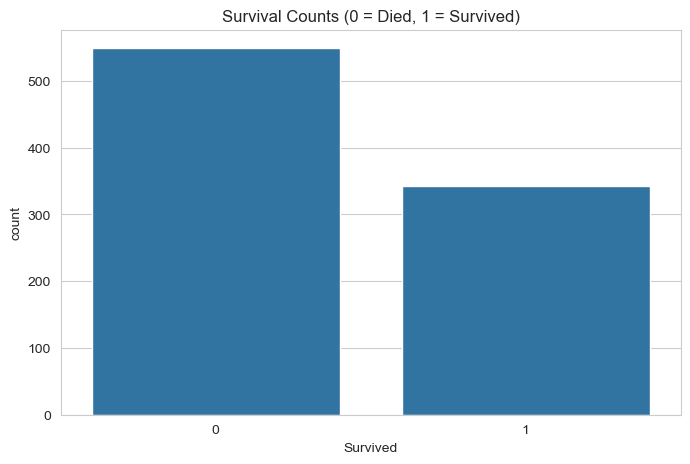

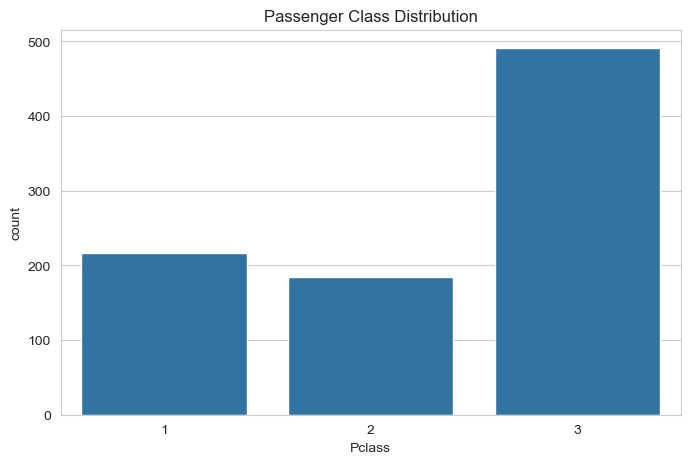

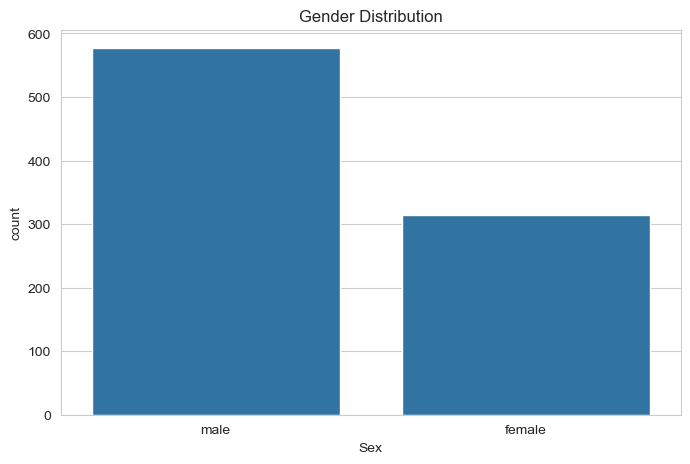

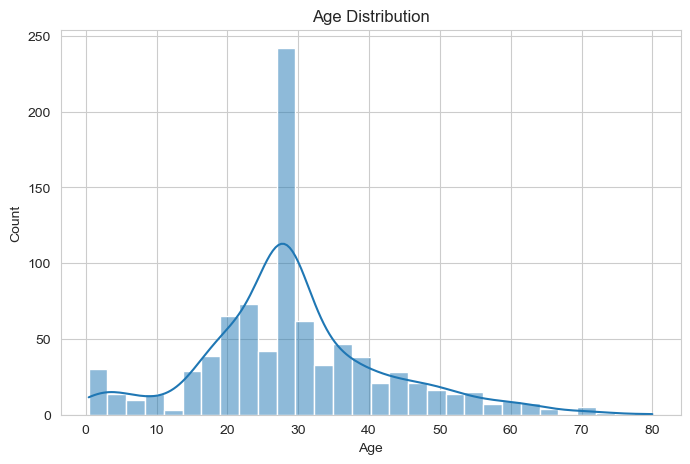

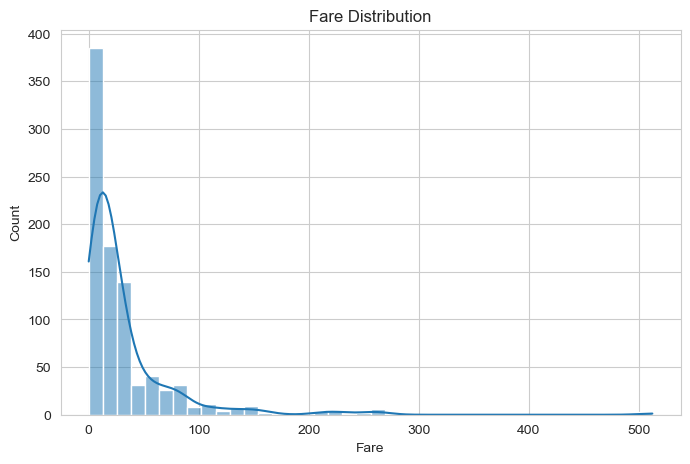

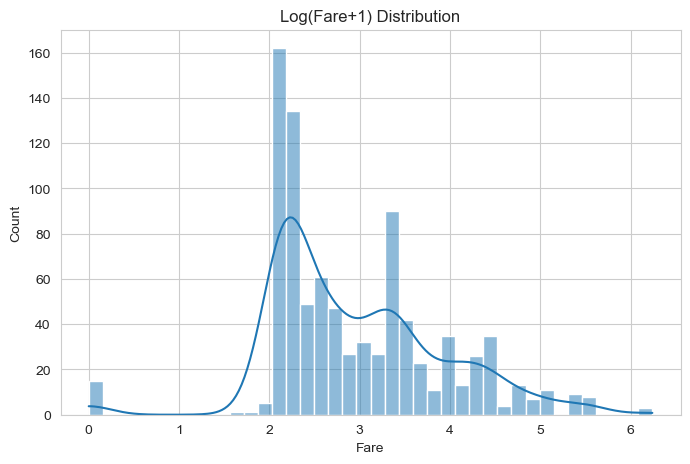

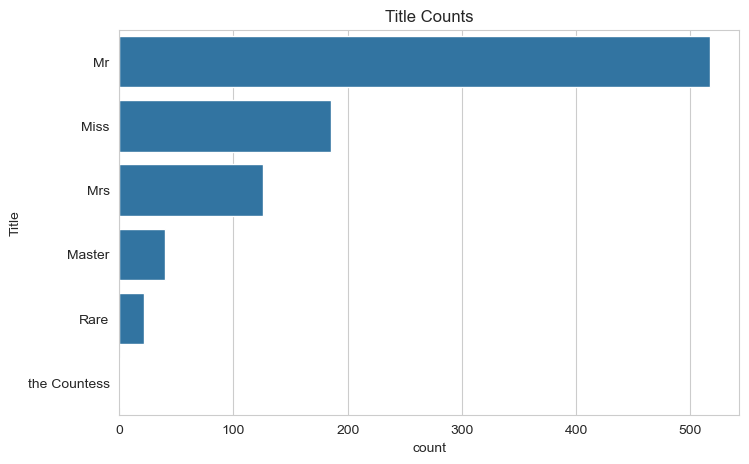

In [15]:
# Survived distribution
sns.countplot(x='Survived', data=df_clean)
plt.title('Survival Counts (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.show()

# Pclass distribution
sns.countplot(x='Pclass', data=df_clean)
plt.title('Passenger Class Distribution')
plt.show()

# Sex distribution
sns.countplot(x='Sex', data=df_clean)
plt.title('Gender Distribution')
plt.show()

# Age distribution
sns.histplot(df_clean['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

# Fare distribution (skewed) 
sns.histplot(df_clean['Fare'], bins=40, kde=True)
plt.title('Fare Distribution')
plt.show()

sns.histplot(np.log1p(df_clean['Fare']), bins=40, kde=True)
plt.title('Log(Fare+1) Distribution')
plt.show()

# Title counts
sns.countplot(y='Title', data=df_clean, order=df_clean['Title'].value_counts().index)
plt.title('Title Counts')
plt.show()


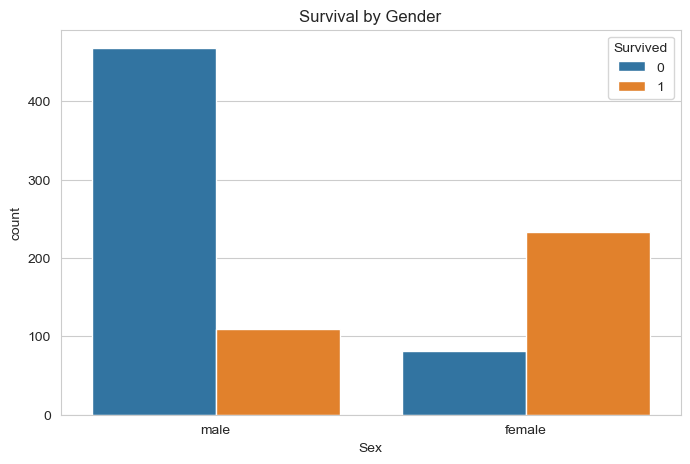

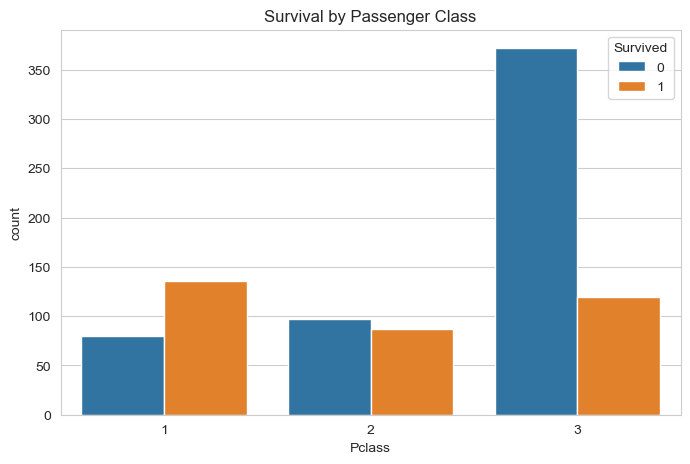

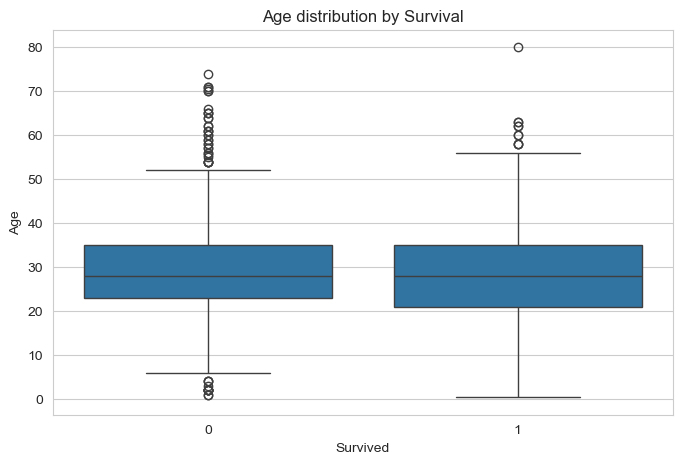

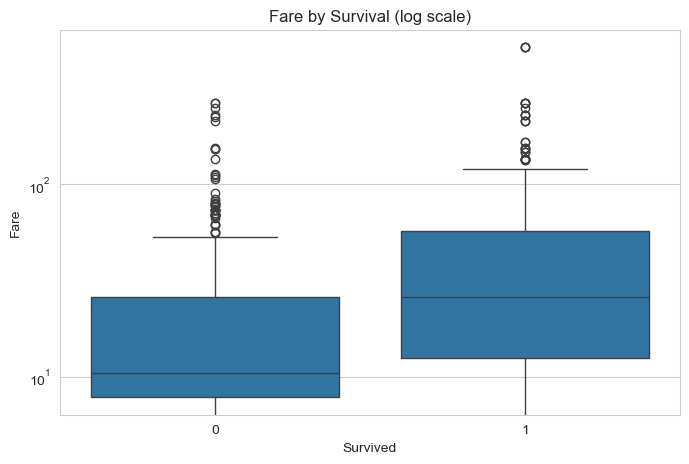

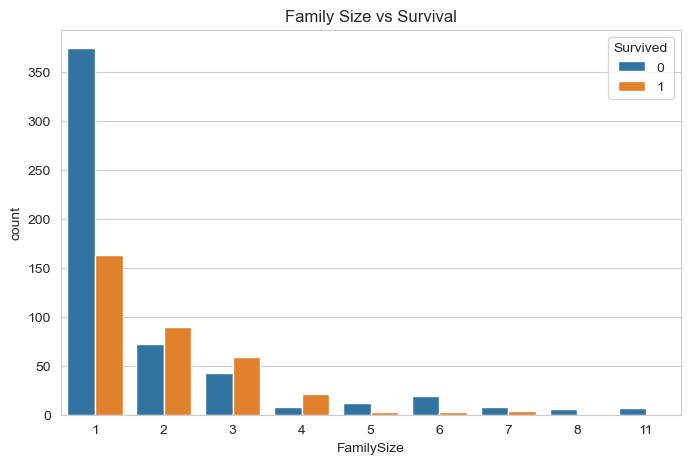

Title
the Countess   1.000
Mrs            0.794
Miss           0.703
Master         0.575
Rare           0.318
Mr             0.157
Name: Survived, dtype: float64

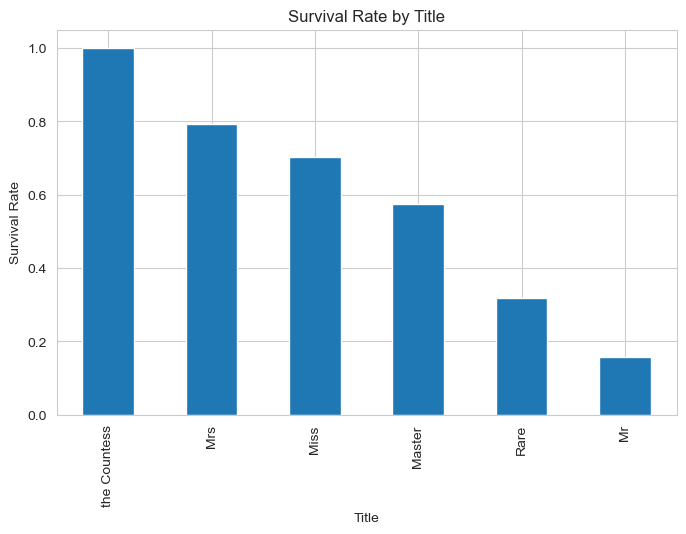

In [16]:
# Survival by Sex
sns.countplot(x='Sex', hue='Survived', data=df_clean)
plt.title('Survival by Gender')
plt.show()

# Survival by Pclass
sns.countplot(x='Pclass', hue='Survived', data=df_clean)
plt.title('Survival by Passenger Class')
plt.show()

# Boxplot Age vs Survived
sns.boxplot(x='Survived', y='Age', data=df_clean)
plt.title('Age distribution by Survival')
plt.show()

# Fare vs Survived (violin/box)
sns.boxplot(x='Survived', y='Fare', data=df_clean)
plt.yscale('log')  # because Fare is skewed
plt.title('Fare by Survival (log scale)')
plt.show()

# FamilySize vs Survival
sns.countplot(x='FamilySize', hue='Survived', data=df_clean)
plt.title('Family Size vs Survival')
plt.show()

# Title vs Survival (use normalized rates)
title_survival = df_clean.groupby('Title')['Survived'].mean().sort_values(ascending=False)
display(title_survival)
title_survival.plot(kind='bar')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Title')
plt.show()


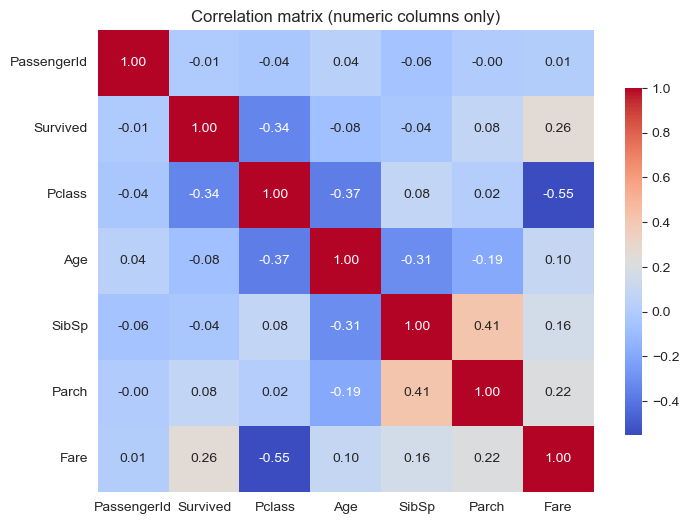

In [21]:
numeric_corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(8,6))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'shrink':.75})
plt.title('Correlation matrix (numeric columns only)')
plt.show()


In [25]:
surv_corr = corr['Survived'].drop('Survived').sort_values(ascending=False)
print("Features most positively correlated with Survived:\n")
print(surv_corr.head(10))
print("\nFeatures most negatively correlated with Survived:\n")
print(surv_corr.tail(10))


Features most positively correlated with Survived:

Sex                   0.543
Title_Mrs             0.342
Title_Miss            0.336
Fare                  0.257
Parch                 0.082
Title_the Countess    0.042
Embarked_Q            0.004
Title_Rare           -0.021
SibSp                -0.035
Age                  -0.065
Name: Survived, dtype: float64

Features most negatively correlated with Survived:

Fare                  0.257
Parch                 0.082
Title_the Countess    0.042
Embarked_Q            0.004
Title_Rare           -0.021
SibSp                -0.035
Age                  -0.065
Embarked_S           -0.150
Pclass               -0.338
Title_Mr             -0.549
Name: Survived, dtype: float64


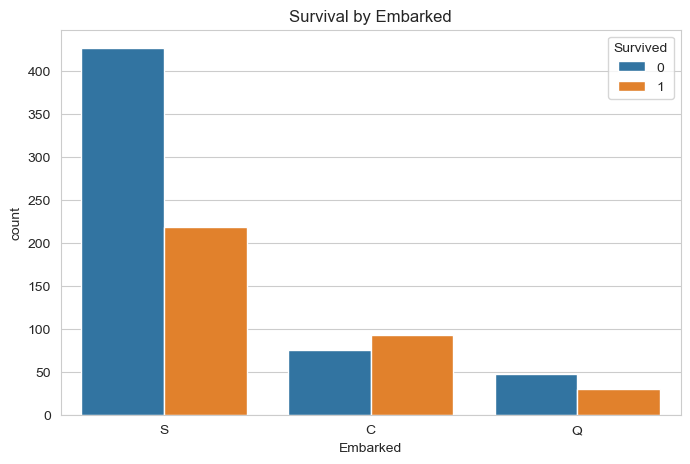

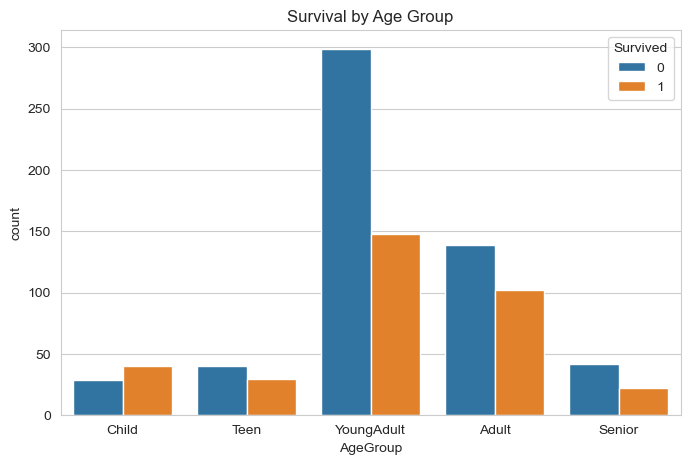

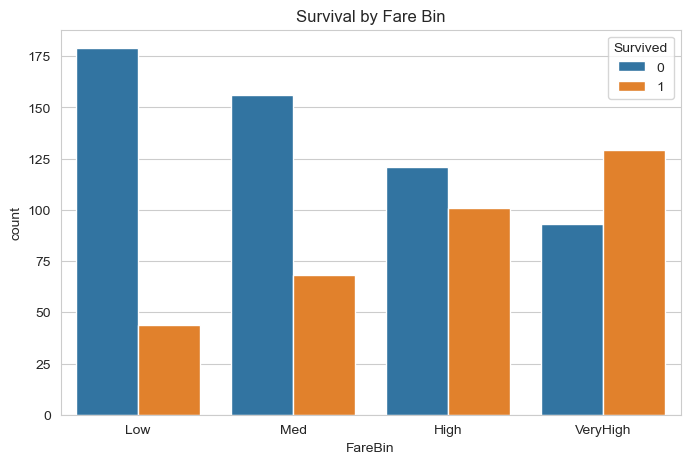

In [27]:
# Survival by Embarked
pd.crosstab(df_clean['Embarked'], df_clean['Survived'], normalize='index')*100

sns.countplot(x='Embarked', hue='Survived', data=df_clean)
plt.title('Survival by Embarked')
plt.show()

# Age groups
bins = [0, 12, 18, 30, 50, 80]
labels = ['Child','Teen','YoungAdult','Adult','Senior']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, include_lowest=True)

pd.crosstab(df_clean['AgeGroup'], df_clean['Survived'], normalize='index')*100

sns.countplot(x='AgeGroup', hue='Survived', data=df_clean)
plt.title('Survival by Age Group')
plt.show()

# Fare bins
df_clean['FareBin'] = pd.qcut(df_clean['Fare'], 4, labels=['Low','Med','High','VeryHigh'])
pd.crosstab(df_clean['FareBin'], df_clean['Survived'], normalize='index')*100

sns.countplot(x='FareBin', hue='Survived', data=df_clean, order=['Low','Med','High','VeryHigh'])
plt.title('Survival by Fare Bin')
plt.show()
